<a href="https://colab.research.google.com/github/Soumyadeep333/slm-from-scratch/blob/main/SLM_FROM_SCRATCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
CKPT_DIR = '/content/drive/MyDrive/SLM_checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

# Restore tokenized data if an earlier session already created it
for f in ['train.bin', 'validation.bin']:
    if not os.path.exists(f) and os.path.exists(f'{CKPT_DIR}/{f}'):
        shutil.copy(f'{CKPT_DIR}/{f}', f)

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')
!ls -lh /content/drive/MyDrive/SLM_checkpoints

Mounted at /content/drive
total 1.4G
-rw------- 1 root root 115M Sep 20 19:29 best_model_params.pt
-rw------- 1 root root 344M Sep 20 19:32 last_checkpoint.pt
-rw------- 1 root root 901M Sep 20 16:05 train.bin
-rw------- 1 root root 9.1M Sep 20 16:05 validation.bin


In [4]:
!pip install tiktoken
import tiktoken
enc = tiktoken.get_encoding("gpt2")

Step 1: Import the Dataset
TinyStories is a synthetic dataset of short stories that only contain words that a typical 3 to 4-year-olds usually understand, generated by GPT-3.5 and GPT-4. We can get it from HuggingFace. **bold text**

In [ ]:
!pip install datasets

In [ ]:
pip install -U datasets

In [ ]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

Step 2: Tokenize the Dataset
In this step, we will do the following:

(1) Tokenize the dataset into tokenIDs.

(2) Create a file called "train.bin" and "validtion.bin" where we will store the tokenIDs from the entire dataset.

(3) We make sure the tokenIDs are stored on a disk, rather than on the RAM for efficient computations. **bold text**

In [ ]:
!pip install tiktoken
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

enc = tiktoken.get_encoding("gpt2")

# Some functions from https://github.com/karpathy/nanoGPT/blob/master/data/openwebtext/prepare.py

def process(example):
    ids = enc.encode_ordinary(example['text']) # encode_ordinary ignores any special tokens
    out = {'ids': ids, 'len': len(ids)}
    return out

if not os.path.exists("train.bin"):
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8,
        )
    # concatenate all the ids in each dataset into one large file we can use for training
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16 # (can do since enc.max_token_value == 50256 is < 2**16)
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            # Batch together samples for faster write
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            # Write into mmap
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()

writing train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

writing validation.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

In [ ]:
!ls -lh *.bin
!ls -lh /content/drive/MyDrive/SLM_checkpoints

-rw-r--r-- 1 root root 901M Sep 20 15:22 train.bin
total 901M
-rw------- 1 root root 901M Sep 20 15:43 train.bin


In [ ]:
!rm -f train.bin validation.bin
!rm -f /content/drive/MyDrive/SLM_checkpoints/train.bin /content/drive/MyDrive/SLM_checkpoints/validation.bin

In [ ]:
!ls -lh *.bin

-rw-r--r-- 1 root root 901M Sep 20 16:04 train.bin
-rw-r--r-- 1 root root 9.1M Sep 20 16:04 validation.bin


In [ ]:
for f in ['train.bin', 'validation.bin']:
    if not os.path.exists(f'{CKPT_DIR}/{f}'):
        shutil.copy(f, f'{CKPT_DIR}/{f}')

**Step 3: Create Input-Output batches for the dataset**

In [ ]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
#block size = context window
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

**Step 4: Define the SLM Model Architecture**

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [6]:
config = GPTConfig(
    vocab_size=50257,     # use the tokenizer's vocab size
    block_size=128,       # or whatever context size you're training with
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

**Step 5: Define the loss function**

In [ ]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

**Step 6: Define SLM Training Configuration Part 1**

In [ ]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 1e-4 #more stable training, earlier 1e-4
max_iters = 20000 #increase from 25000
warmup_steps = 1000 #smoother initial train, earlier 100
min_lr = 5e-4 #lower rate, earlier 5e-4
eval_iters = 500 # increased from 100
batch_size = 32 # changed from 16, better gradient estimate
block_size = 128 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

**Step 7: Define SLM Training Configuration Part 2**

In [ ]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

/tmp/ipykernel_2425/2132813893.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


**Step 8: Pre-train the SLM**

In [ ]:
best_val_loss = float('inf')
best_model_params_path = f"{CKPT_DIR}/best_model_params.pt"   # now on Drive
CKPT_PATH = f"{CKPT_DIR}/last_checkpoint.pt"
ckpt_every = gradient_accumulation_steps * 20   # 640 iters; must be a multiple of gradient_accumulation_steps
train_loss_list, validation_loss_list = [], []
start_epoch = 0

def save_checkpoint(next_epoch):
    tmp = CKPT_PATH + ".tmp"
    torch.save({
        "epoch": next_epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "best_val_loss": best_val_loss,
        "train_loss_list": train_loss_list,
        "validation_loss_list": validation_loss_list,
    }, tmp)
    os.replace(tmp, CKPT_PATH)   # a crash mid-save can't corrupt the last good checkpoint

model = model.to(device)

# Auto-resume if a checkpoint exists
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    scaler.load_state_dict(ckpt["scaler"])
    best_val_loss = ckpt["best_val_loss"]
    train_loss_list = ckpt["train_loss_list"]
    validation_loss_list = ckpt["validation_loss_list"]
    start_epoch = ckpt["epoch"]
    print(f"Resumed from iteration {start_epoch}")

for epoch in tqdm(range(start_epoch, max_iters), initial=start_epoch, total=max_iters):
    if epoch % eval_iters == 0 and epoch != 0:
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

    if (epoch + 1) % ckpt_every == 0:
        save_checkpoint(epoch + 1)

save_checkpoint(max_iters)   # final save

  0%|          | 0/20000 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 500: train loss 9.4362, val loss 9.4419
The current learning rate: 0.00007
Epoch 1000: train loss 8.4979, val loss 8.5019
The current learning rate: 0.00010
Epoch 1500: train loss 7.5368, val loss 7.5328
The current learning rate: 0.00010
Epoch 2000: train loss 6.6871, val loss 6.6813
The current learning rate: 0.00010
Epoch 2500: train loss 5.9964, val loss 5.9899
The current learning rate: 0.00011
Epoch 3000: train loss 5.4936, val loss 5.4877
The current learning rate: 0.00011
Epoch 3500: train loss 5.0695, val loss 5.0671
The current learning rate: 0.00012
Epoch 4000: train loss 4.7531, val loss 4.7517
The current learning rate: 0.00012
Epoch 4500: train loss 4.5030, val loss 4.5060
The current learning rate: 0.00013
Epoch 5000: train loss 4.2867, val loss 4.2911
The current learning rate: 0.00014
Epoch 5500: train loss 4.1215, val loss 4.1213
The current learning rate: 0.00015
Epoch 6000: train loss 3.9793, val loss 3.9765
The current learning rate: 0.00016
Epoch 6500: train

**Step 9: Plot the SLM Loss Function**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
39 evaluation points


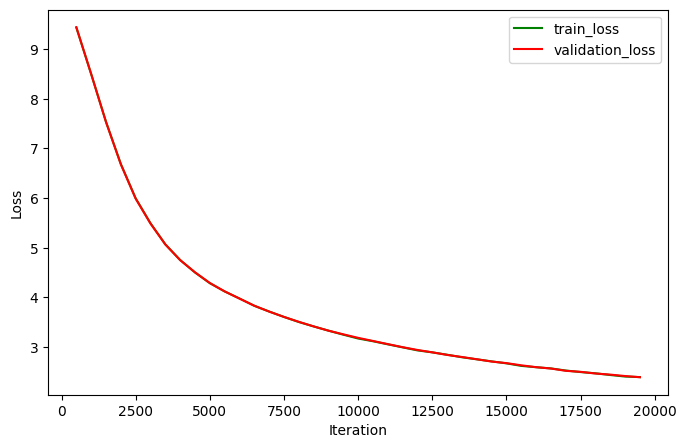

In [11]:
import torch
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

ckpt = torch.load("/content/drive/MyDrive/SLM_checkpoints/last_checkpoint.pt",
                  map_location="cpu", weights_only=False)
train_l = [float(x) for x in ckpt["train_loss_list"]]
val_l = [float(x) for x in ckpt["validation_loss_list"]]
print(len(train_l), "evaluation points")

x = [500 * (i + 1) for i in range(len(train_l))]
plt.figure(figsize=(8, 5))
plt.plot(x, train_l, 'g', label='train_loss')
plt.plot(x, val_l, 'r', label='validation_loss')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Step 10: Run SLM Inference on our trained model**

In [7]:
#Load the model
model = GPT(config)  # re-create the model with same config
device = "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "/content/drive/MyDrive/SLM_checkpoints/best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states

<All keys matched successfully>

In [8]:
sentence = "Once upon a time there was a pumpkin."
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

Once upon a time there was a pumpkin. It was a very special world. One day, it was the most amazing star was disappeared!

"Wow!" said happily it.


The rainbow was so colorful, it made it even danced a big difference in the clock.

The sun couldn't wait to see the reef. All the colors of the light would see the new thing that saw it was covered her because it was deep in the sky.

"Can I see the gardens?" the pumpkin said the poppy.

"Yes, beef is very clear!" said the flower.

They jumped around and shouted very carefully, and oranges. They made rare things in the sky. They were now yummy to Ella and was so glad to see her jokes: he got pink crayon!Once upon a time, there was a little girl. She wanted to create something new - it was a beautiful dress! She thought and thought it loved all the things in her favourite envelope. But one


In [9]:
sentence = "A little girl went to the woods"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

A little girl went to the woods to see what was inside me. She saw Sandy in the corner, looking and pretending to be a little ignorant rabbit. Justin asked his mum if she found a hole in front of them. 

The fox smiled and followed the ants while they were about. Soon the wind shone high on the sides and caused the safety. Inside, it was nothing so bad at the hospital and it was an satisfied. The little girl was so content that, it started to get happy. 

The little girl returned and thanked the hunter for the rest of the day. Every day every day, she went back to the forest and met lots of new friends. The end.Once upon a time, there was a little girl. She loved to play a sunshine, especially afternoon because she smiled happily and started to make bouncing her feel brave. 

One day, a princess came to her house. She made her like the flowers and it hers. But the princess was very unlucky. She felt


In [ ]:
from google.colab import runtime
runtime.unassign()